===== ID3 (Entropy) Results =====
Accuracy: 0.875
Precision: 0.8888888888888888
Recall: 0.8888888888888888
F1 Score: 0.8666666666666667

Confusion Matrix
[[2 0 0]
 [1 2 0]
 [0 0 3]]

Classification Report
              precision    recall  f1-score   support

       Small       0.67      1.00      0.80         2
      Medium       1.00      0.67      0.80         3
       Large       1.00      1.00      1.00         3

    accuracy                           0.88         8
   macro avg       0.89      0.89      0.87         8
weighted avg       0.92      0.88      0.88         8



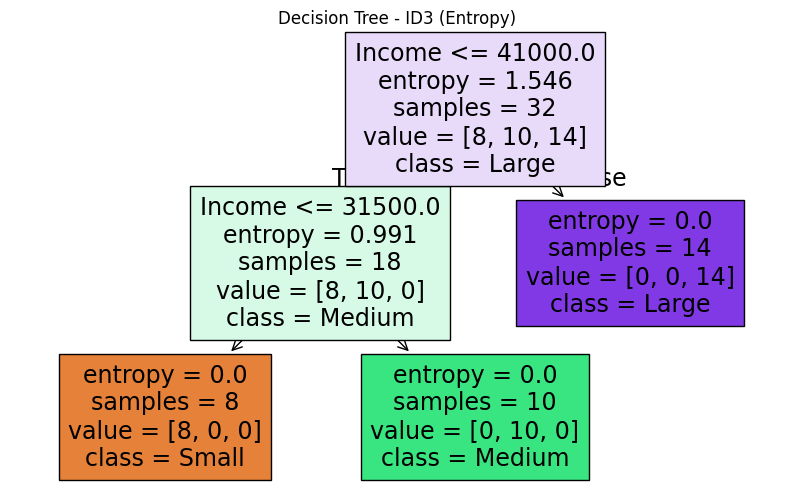

|--- Income <= 41000.00
|   |--- Income <= 31500.00
|   |   |--- class: 0
|   |--- Income >  31500.00
|   |   |--- class: 1
|--- Income >  41000.00
|   |--- class: 2


===== CART (Gini) Results =====
Accuracy: 0.875
Precision: 0.8888888888888888
Recall: 0.8888888888888888
F1 Score: 0.8666666666666667

Confusion Matrix
[[2 0 0]
 [1 2 0]
 [0 0 3]]

Classification Report
              precision    recall  f1-score   support

       Small       0.67      1.00      0.80         2
      Medium       1.00      0.67      0.80         3
       Large       1.00      1.00      1.00         3

    accuracy                           0.88         8
   macro avg       0.89      0.89      0.87         8
weighted avg       0.92      0.88      0.88         8



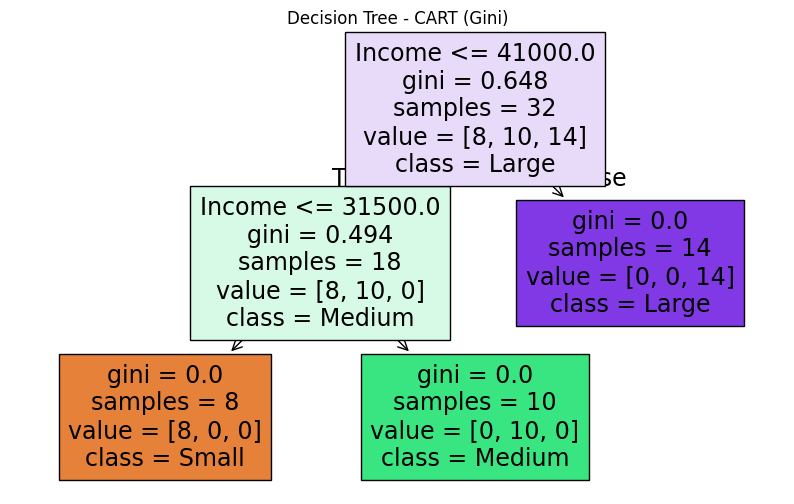

|--- Income <= 41000.00
|   |--- Income <= 31500.00
|   |   |--- class: 0
|   |--- Income >  31500.00
|   |   |--- class: 1
|--- Income >  41000.00
|   |--- class: 2



In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("loan_data.csv")

# Create 3-class target from LoanAmount
# 0 = Small Loan
# 1 = Medium Loan
# 2 = Large Loan

loan = df["LoanAmount"]

conditions = [
    loan < 10000,
    (loan >= 10000) & (loan < 20000),
    loan >= 20000
]

choices = [0,1,2]

df["LoanClass"] = np.select(conditions, choices)

# Features and target
X = df[["CreditScore","Income","EmploymentYears"]]
y = df["LoanClass"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ========================
# ID3 Decision Tree
# ========================

id3_tree = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

id3_tree.fit(X_train, y_train)

y_pred_id3 = id3_tree.predict(X_test)

print("===== ID3 (Entropy) Results =====")

print("Accuracy:", accuracy_score(y_test, y_pred_id3))

print("Precision:", precision_score(y_test, y_pred_id3, average="macro"))
print("Recall:", recall_score(y_test, y_pred_id3, average="macro"))
print("F1 Score:", f1_score(y_test, y_pred_id3, average="macro"))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_id3))

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred_id3,
    target_names=["Small","Medium","Large"]
))

plt.figure(figsize=(10,6))

plot_tree(
    id3_tree,
    feature_names=X.columns,
    class_names=["Small","Medium","Large"],
    filled=True
)

plt.title("Decision Tree - ID3 (Entropy)")
plt.show()

print(export_text(id3_tree, feature_names=list(X.columns)))

# ========================
# CART Decision Tree
# ========================

cart_tree = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

cart_tree.fit(X_train, y_train)

y_pred_cart = cart_tree.predict(X_test)

print("\n===== CART (Gini) Results =====")

print("Accuracy:", accuracy_score(y_test, y_pred_cart))

print("Precision:", precision_score(y_test, y_pred_cart, average="macro"))
print("Recall:", recall_score(y_test, y_pred_cart, average="macro"))
print("F1 Score:", f1_score(y_test, y_pred_cart, average="macro"))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_cart))

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred_cart,
    target_names=["Small","Medium","Large"]
))

plt.figure(figsize=(10,6))

plot_tree(
    cart_tree,
    feature_names=X.columns,
    class_names=["Small","Medium","Large"],
    filled=True
)

plt.title("Decision Tree - CART (Gini)")
plt.show()

print(export_text(cart_tree, feature_names=list(X.columns)))